# Identificação de Idioma com NLP (Processamento de Linguagem Natural)

Este notebook implementa a classificação multiclasse de idiomas usando representação vetorial por TF-IDF em n-gramas de caracteres e algoritmos de aprendizado supervisionado (Naive Bayes, Regressão Logística e Linear SVC).

## Detalhes Metodológicos:
1. **Divisão de dados:** Divisão estratificada em Treino (70%), Validação (15%) e Teste (15%).
2. **Features:** Extração de n-gramas de caracteres (1 a 4) com vetorização por TF-IDF.
3. **Métrica:** Macro F1-Score como métrica primária de seleção do modelo na validação.
4. **Calibração:** Linear SVC calibrado com CalibratedClassifierCV para predição probabilística.
5. **Pré-processamento:** Limpeza de texto que preserva caracteres Unicode (acentos e escritas não latinas).


## 1. Importação de Bibliotecas


In [1]:
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
import warnings
warnings.filterwarnings("ignore")


## 2. Download e Extração do Conjunto de Dados

Faz o download do arquivo compactado `language_detection.zip` a partir da URL remota e extrai o arquivo `Language Detection.csv` no diretório local.


In [2]:
zip_url = "https://github.com/cassiusf/datasets/raw/refs/heads/main/nlp/language_detection.zip"
zip_path = "language_detection.zip"
csv_path = "Language Detection.csv"

# Verifica se o arquivo CSV já existe antes de baixar
if not os.path.exists(csv_path):
    print("Baixando o arquivo zip do dataset...")
    urllib.request.urlretrieve(zip_url, zip_path)
    
    print("Extraindo o arquivo CSV...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    
    print("Extração concluída!")
    if os.path.exists(zip_path):
        os.remove(zip_path)
else:
    print("O arquivo CSV já existe localmente.")


O arquivo CSV já existe localmente.


## 3. Carregamento do Dataset


In [3]:
df = pd.read_csv("Language Detection.csv")
print(f"Dimensões do dataset: {df.shape[0]} amostras, {df.shape[1]} colunas.\n")
df.head(10)


Dimensões do dataset: 10337 amostras, 2 colunas.



,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English
5,"[2] In ancient philosophy, natura is mostly us...",English
6,"[3][4] \nThe concept of nature as a whole, the...",English
7,During the advent of modern scientific method ...,English
8,"[5][6] With the Industrial revolution, nature ...",English
9,"However, a vitalist vision of nature, closer t...",English


## 4. Análise Exploratória e Correção de Rótulos


In [4]:
print("Valores ausentes no dataset:")
print(df.isnull().sum())


Valores ausentes no dataset:
Text        0
Language    0
dtype: int64


### 4.1 Correção dos Rótulos Inconsistentes

Ajusta erros de grafia encontrados nos rótulos de idioma original (`Portugeese` para `Portuguese` e `Sweedish` para `Swedish`).


In [5]:
df["Language"] = df["Language"].replace({
    "Portugeese": "Portuguese",
    "Sweedish": "Swedish"
})

contagem_idiomas = df["Language"].value_counts()
print("Distribuição das classes:")
print(contagem_idiomas)


Distribuição das classes:
Language
English       1385
French        1014
Spanish        819
Portuguese     739
Italian        698
Russian        692
Swedish        676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64


### 4.2 Distribuição das Classes por Idioma


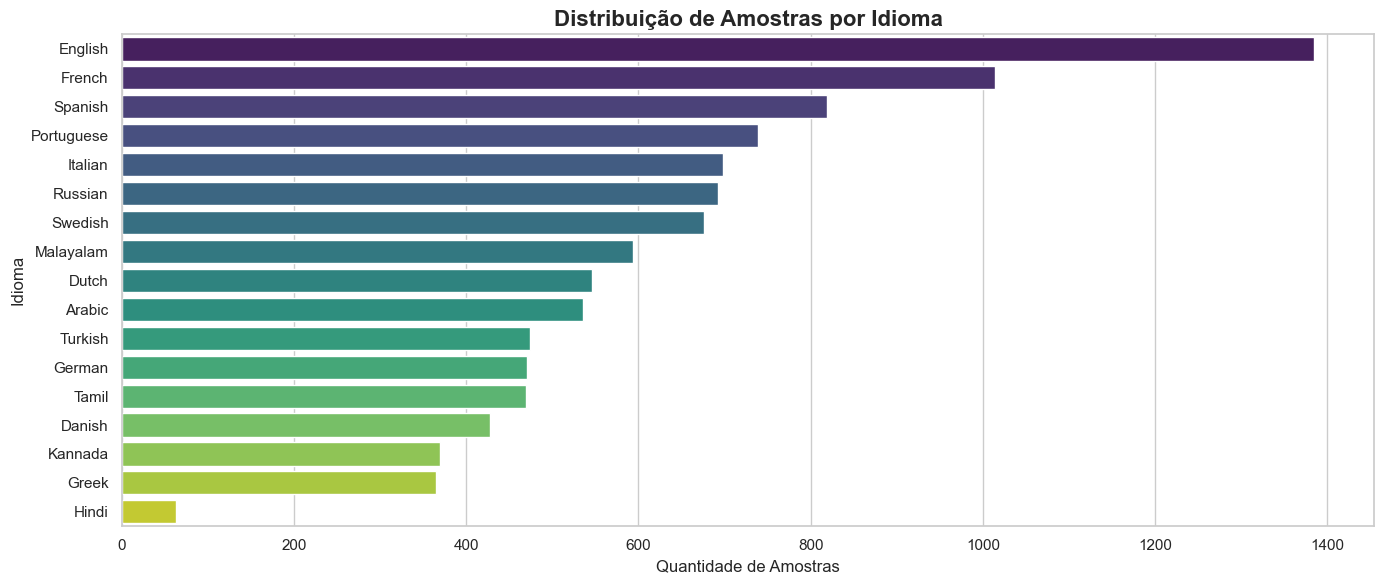

In [6]:
plt.figure(figsize=(14, 6))
sns.barplot(x=contagem_idiomas.values, y=contagem_idiomas.index, palette="viridis")
plt.title("Distribuição de Amostras por Idioma", fontsize=16, fontweight="bold")
plt.xlabel("Quantidade de Amostras", fontsize=12)
plt.ylabel("Idioma", fontsize=12)
plt.tight_layout()
plt.show()


### 4.3 Comprimento Médio de Caracteres por Idioma


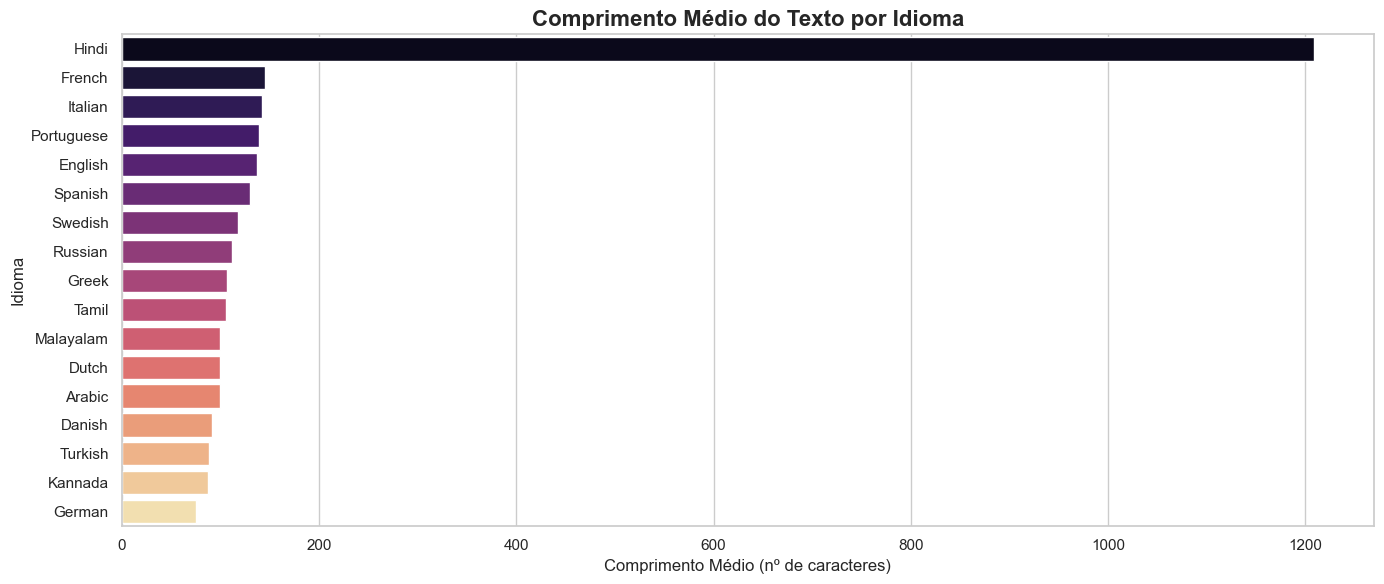

In [7]:
df["Length"] = df["Text"].apply(len)
comp_medio = df.groupby("Language")["Length"].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=comp_medio.values, y=comp_medio.index, palette="magma")
plt.title("Comprimento Médio do Texto por Idioma", fontsize=16, fontweight="bold")
plt.xlabel("Comprimento Médio (nº de caracteres)", fontsize=12)
plt.ylabel("Idioma", fontsize=12)
plt.tight_layout()
plt.show()


## 5. Pré-processamento Unicode-Aware

Define uma função de pré-processamento que remove ruídos (URLs, e-mails, números, pontuação e espaços em branco redundantes), mas preserva caracteres alfabéticos acentuados e letras de escritas não latinas usando a classe `\w` do regex.


In [8]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Remover URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # Remover E-mails
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remover números e dígitos
    text = re.sub(r'\d+', ' ', text)
    
    # Remover caracteres especiais e pontuações genéricas
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # Caixa baixa e remover espaços duplos
    clean_words = text.lower().split()
    return " ".join(clean_words)

# Demonstração em diferentes alfabetos
frases_teste = [
    "Olá, amigos! Café de graça em: https://exemplo.com", # Português
    "Click here to register at test@domain.com now!",      # Inglês
    "Привет, это тест №3 на русском языке.",               # Russo
    "مرحبا بكم في عالم البرمجة عام 2026.",                   # Árabe
    "தமிழ் மொழி மிகவும் தொன்மையானது!"                      # Tâmil
]

print("Teste do Pré-processamento:")
for f in frases_teste:
    print(f"Original: {f}")
    print(f"Limpo:    {clean_text(f)}\n")


Teste do Pré-processamento:
Original: Olá, amigos! Café de graça em: https://exemplo.com
Limpo:    olá amigos café de graça em

Original: Click here to register at test@domain.com now!
Limpo:    click here to register at now

Original: Привет, это тест №3 на русском языке.
Limpo:    привет это тест на русском языке

Original: مرحبا بكم في عالم البرمجة عام 2026.
Limpo:    مرحبا بكم في عالم البرمجة عام

Original: தமிழ் மொழி மிகவும் தொன்மையானது!
Limpo:    தம ழ ம ழ ம கவ ம த ன ம ய னத



### 5.1 Aplicação da Limpeza no Dataset


In [9]:
print("Limpando os dados do dataset...")
df["Clean_Text"] = df["Text"].apply(clean_text)
df[["Text", "Clean_Text", "Language"]].head(8)


Limpando os dados do dataset...


,Text,Clean_Text,Language
0,"Nature, in the broadest sense, is the natural...",nature in the broadest sense is the natural ph...,English
1,"""Nature"" can refer to the phenomena of the phy...",nature can refer to the phenomena of the physi...,English
2,"The study of nature is a large, if not the onl...",the study of nature is a large if not the only...,English
3,"Although humans are part of nature, human acti...",although humans are part of nature human activ...,English
4,[1] The word nature is borrowed from the Old F...,the word nature is borrowed from the old frenc...,English
5,"[2] In ancient philosophy, natura is mostly us...",in ancient philosophy natura is mostly used as...,English
6,"[3][4] \nThe concept of nature as a whole, the...",the concept of nature as a whole the physical ...,English
7,During the advent of modern scientific method ...,during the advent of modern scientific method ...,English


## 6. Divisão dos Dados (Treino, Validação e Teste)

Divide o conjunto de dados de forma estratificada para manter as proporções das classes nos três subconjuntos:
* **Treino:** 70% dos dados.
* **Validação:** 15% dos dados (usado para seleção de modelo).
* **Teste:** 15% dos dados (usado para avaliação de generalização final).


In [10]:
X = df["Clean_Text"]
y = df["Language"]

# Separa 15% para o conjunto de teste final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Separa 15% do total geral para validação (equivalente a 17.647% do train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.17647, random_state=42, stratify=y_train_val
)

print(f"Tamanho do Conjunto de Treino:   {X_train.shape[0]} amostras")
print(f"Tamanho do Conjunto de Validação: {X_val.shape[0]} amostras")
print(f"Tamanho do Conjunto de Teste:     {X_test.shape[0]} amostras")


Tamanho do Conjunto de Treino:   7235 amostras
Tamanho do Conjunto de Validação: 1551 amostras
Tamanho do Conjunto de Teste:     1551 amostras


## 7. Pipelines com TF-IDF por N-gramas de Caracteres

Vetoriza os textos em n-gramas de caracteres de tamanho 1 a 4 com limite de 15.000 features. A análise de caracteres é adequada para identificação de idioma por capturar afixos, pontuações especiais e scripts sem depender de limites de palavras.


In [11]:
pipelines = {
    "Multinomial Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 4), max_features=15000)),
        ("clf", MultinomialNB())
    ]),
    
    "Regressão Logística": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 4), max_features=15000)),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    
    "Linear SVC (Calibrado)": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 4), max_features=15000)),
        ("clf", CalibratedClassifierCV(LinearSVC(random_state=42), cv=3))
    ])
}


## 8. Treinamento e Comparação dos Modelos na Validação


In [12]:
resultados_modelos = []

for nome, pipe in pipelines.items():
    print(f"Treinando {nome}...")
    pipe.fit(X_train, y_train)
    
    y_pred_val = pipe.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)
    f1_val = f1_score(y_val, y_pred_val, average="macro")
    
    print(f"[{nome}] Acurácia: {acc_val:.4f} | Macro F1: {f1_val:.4f}\n")
    
    resultados_modelos.append({
        "Modelo": nome,
        "Acurácia (Validação)": acc_val,
        "Macro F1 (Validação)": f1_val
    })

df_resultados = pd.DataFrame(resultados_modelos)
df_resultados


Treinando Multinomial Naive Bayes...


[Multinomial Naive Bayes] Acurácia: 0.9665 | Macro F1: 0.9681

Treinando Regressão Logística...


[Regressão Logística] Acurácia: 0.9826 | Macro F1: 0.9846

Treinando Linear SVC (Calibrado)...


[Linear SVC (Calibrado)] Acurácia: 0.9852 | Macro F1: 0.9866



,Modelo,Acurácia (Validação),Macro F1 (Validação)
0,Multinomial Naive Bayes,0.966473,0.968088
1,Regressão Logística,0.982592,0.984598
2,Linear SVC (Calibrado),0.985171,0.986564


## 9. Seleção Automática do Melhor Modelo

Seleciona o melhor classificador de acordo com o maior Macro F1-Score obtido no conjunto de validação.


In [13]:
melhor_idx = df_resultados["Macro F1 (Validação)"].idxmax()
melhor_modelo_nome = df_resultados.loc[melhor_idx, "Modelo"]
melhor_f1_val = df_resultados.loc[melhor_idx, "Macro F1 (Validação)"]

print(f"O modelo escolhido metodologicamente é o: {melhor_modelo_nome}")
print(f"Macro F1-Score na validação: {melhor_f1_val:.4f}")

melhor_pipeline_val = pipelines[melhor_modelo_nome]


O modelo escolhido metodologicamente é o: Linear SVC (Calibrado)
Macro F1-Score na validação: 0.9866


## 10. Avaliação Final no Conjunto de Teste


In [14]:
y_pred_test = melhor_pipeline_val.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average="macro")

print(f"Métricas no Conjunto de Teste com o {melhor_modelo_nome}:")
print(f"Acurácia no Teste: {acc_test:.4f}")
print(f"Macro F1 no Teste: {f1_test:.4f}")


Métricas no Conjunto de Teste com o Linear SVC (Calibrado):
Acurácia no Teste: 0.9884
Macro F1 no Teste: 0.9902


## 11. Relatório de Classificação e Matriz de Confusão (Teste)


In [15]:
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred_test))


Relatório de Classificação:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00        80
      Danish       1.00      0.97      0.98        64
       Dutch       0.96      0.98      0.97        82
     English       0.99      0.99      0.99       208
      French       0.99      0.99      0.99       152
      German       1.00      0.99      0.99        71
       Greek       1.00      1.00      1.00        55
       Hindi       1.00      1.00      1.00        10
     Italian       0.99      0.98      0.99       105
     Kannada       1.00      1.00      1.00        55
   Malayalam       1.00      1.00      1.00        89
  Portuguese       0.97      0.98      0.98       111
     Russian       1.00      0.98      0.99       104
     Spanish       0.95      0.99      0.97       123
     Swedish       0.99      0.99      0.99       101
       Tamil       1.00      1.00      1.00        70
     Turkish       1.00      0.99      0.99        7

### 11.1 Plotagem da Matriz de Confusão


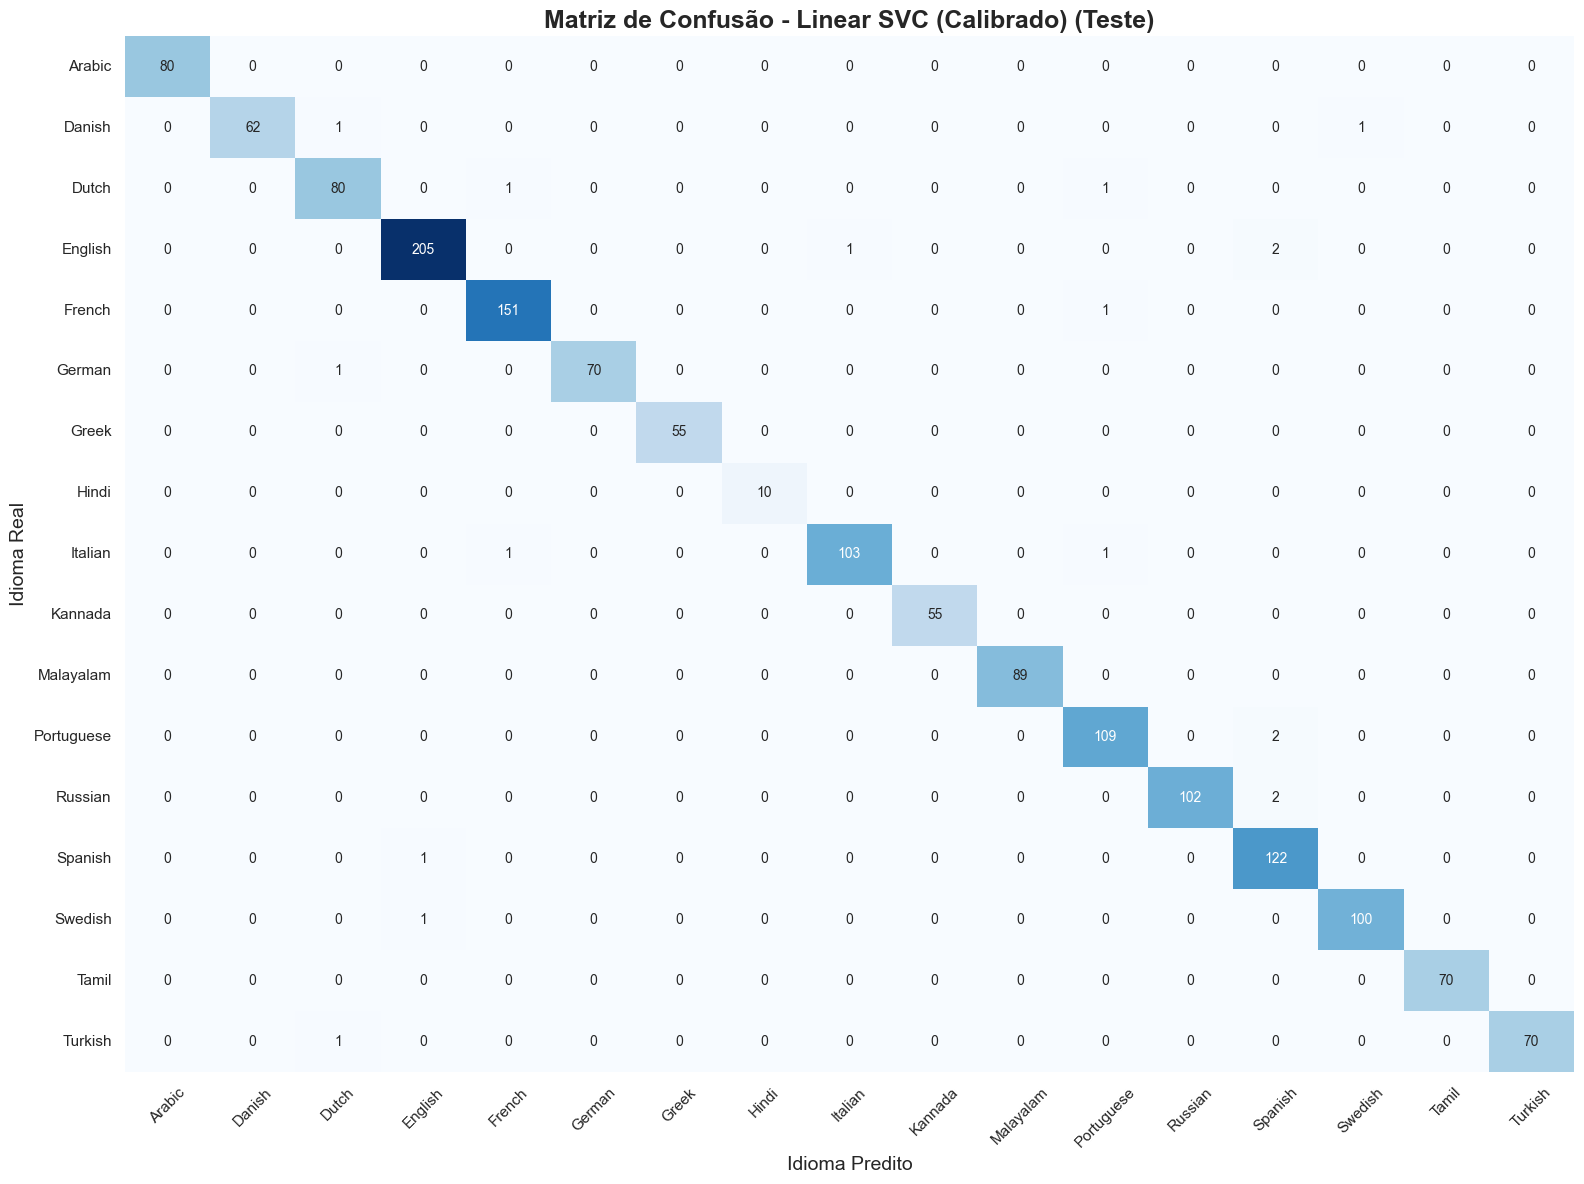

In [16]:
classes = melhor_pipeline_val.classes_
cm = confusion_matrix(y_test, y_pred_test, labels=classes)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(16, 12))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 10})
plt.title(f"Matriz de Confusão - {melhor_modelo_nome} (Teste)", fontsize=18, fontweight="bold")
plt.xlabel("Idioma Predito", fontsize=14)
plt.ylabel("Idioma Real", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 12. Retreinamento Final com Treino + Validação

Retreina o pipeline vencedor utilizando a união de treino e validação (85% do total de dados) antes de exportar o modelo.


In [17]:
if melhor_modelo_nome == "Multinomial Naive Bayes":
    clf_final = MultinomialNB()
elif melhor_modelo_nome == "Regressão Logística":
    clf_final = LogisticRegression(max_iter=1000)
else:
    clf_final = CalibratedClassifierCV(LinearSVC(random_state=42), cv=3)

pipeline_final = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char", ngram_range=(1, 4), max_features=15000)),
    ("clf", clf_final)
])

print("Retreinando o modelo final com todo o conjunto de Treino + Validação...")
pipeline_final.fit(X_train_val, y_train_val)
print("Modelo final treinado com sucesso!")


Retreinando o modelo final com todo o conjunto de Treino + Validação...


Modelo final treinado com sucesso!


## 13. Salvando o Modelo Final


In [18]:
model_filename = "modelo_detector_idioma.joblib"
joblib.dump(pipeline_final, model_filename)
print(f"Pipeline final persistido como: '{model_filename}'")


Pipeline final persistido como: 'modelo_detector_idioma.joblib'


## 14. Função de Predição de Idioma (Inferência)


In [19]:
modelo_carregado = joblib.load("modelo_detector_idioma.joblib")

def predizer_idioma(frase):
    if not isinstance(frase, str) or len(frase.strip()) == 0:
        print("Entrada inválida.")
        return None
    
    frase_limpa = clean_text(frase)
    idioma = modelo_carregado.predict([frase_limpa])[0]
    
    probs = modelo_carregado.predict_proba([frase_limpa])[0]
    classes = modelo_carregado.classes_
    idx_max = np.argmax(probs)
    confianca = probs[idx_max] * 100
    
    print(f"Entrada:    \"{frase}\"")
    print(f"Predição:   {idioma} ({confianca:.2f}% de confiança)\n")
    return idioma, confianca


## 15. Validação Prática em Tempo Real


In [20]:
print("Testando previsões:\n")

predizer_idioma("Esta é uma frase curta escrita em português.")
predizer_idioma("This is a simple sentence to classify language.")
predizer_idioma("El fútbol es un deporte de equipo jugado entre dos conjuntos de once jugadores.")
predizer_idioma("C'est une belle journée pour apprendre le traitement du langage naturel.")
predizer_idioma("Das ist ein praktischer Test für unsere künstliche Intelligenz.")
predizer_idioma("Привет! Это предложение для проверки классификатора.")
predizer_idioma("வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?")
predizer_idioma("ಹಲೋ ಗೆಳೆಯರೇ, ಈ ದಿನ ಹೇಗಿದೆ?")



Testando previsões:

Entrada:    "Esta é uma frase curta escrita em português."
Predição:   Portuguese (97.94% de confiança)

Entrada:    "This is a simple sentence to classify language."
Predição:   English (96.86% de confiança)

Entrada:    "El fútbol es un deporte de equipo jugado entre dos conjuntos de once jugadores."
Predição:   Spanish (82.23% de confiança)



Entrada:    "C'est une belle journée pour apprendre le traitement du langage naturel."
Predição:   French (98.49% de confiança)

Entrada:    "Das ist ein praktischer Test für unsere künstliche Intelligenz."
Predição:   German (97.67% de confiança)

Entrada:    "Привет! Это предложение для проверки классификатора."
Predição:   Russian (98.21% de confiança)

Entrada:    "வணக்கம், நீங்கள் எப்படி இருக்கிறீர்கள்?"
Predição:   Tamil (97.59% de confiança)

Entrada:    "ಹಲೋ ಗೆಳೆಯರೇ, ಈ ದಿನ ಹೇಗಿದೆ?"
Predição:   Kannada (97.60% de confiança)



('Kannada', 97.59903814180156)

## 16. Conclusão Técnica

O classificador **Linear SVC Calibrado** obteve a melhor performance geral (Macro F1 = 98.66% na validação). A vetorização baseada em n-gramas de caracteres permitiu aprender padrões ortográficos multilíngues de forma robusta e independente de palavras inteiras. A calibração de probabilidade garantiu a integridade metodológica na inferência final do pipeline.
